In [1]:
#!pip install "transformers==4.44.0"

In [2]:
#!pip install tf-keras

In [3]:
import pandas as pd
import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from sklearn.model_selection import train_test_split

In [4]:
import json

with open("merged_dataset.jsonl", "r", encoding="utf-8") as f:
    data = [json.loads(line) for line in f]

df = pd.DataFrame(data)

In [5]:
def label_map(label):
    if label == "AI":
        return 1
    else:
        return 0

df["label"] = df["label"].apply(label_map)

X = df["text"].tolist()
y = df["label"].tolist()


train_texts, val_texts, train_labels, val_labels = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(df["label"].value_counts())

label
0    3060
1    3060
Name: count, dtype: int64


In [6]:
print(df.shape)
print(df.head())

(6120, 7)
                                                text  label AI_used  chunk_no  \
0  engineering (an existing interface is user req...      0    none         1   
1  duction, automated or not. formation, software...      0    none         2   
2  one interactive application to another. In thi...      0    none         3   
3  Of course, a tool may induce some method, but ...      0    none         4   
4  UIs and to introduce based on explicit transfo...      0    none         5   

   source                                         source_url  \
0       1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   
1       1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   
2       1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   
3       1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   
4       1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   

   year_of_publication  
0                 2008  
1                 2008  
2                 2008  
3                 

In [7]:
tokenizer = AutoTokenizer.from_pretrained("FacebookAI/xlm-roberta-base")
max_length = 512

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length = max_length,
    return_tensors='tf'
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length = max_length,
    return_tensors='tf'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [8]:
print("Num examples in encodings:", train_encodings["input_ids"].shape[0])
print("Num labels:", len(train_labels))

Num examples in encodings: 4896
Num labels: 4896


In [9]:
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    train_labels
))

val_dataset = tf.data.Dataset.from_tensor_slices((
    dict(val_encodings),
    val_labels
))

In [10]:
print("Shape df:", df.shape)
print(df.head())

Shape df: (6120, 7)
                                                text  label AI_used  chunk_no  \
0  engineering (an existing interface is user req...      0    none         1   
1  duction, automated or not. formation, software...      0    none         2   
2  one interactive application to another. In thi...      0    none         3   
3  Of course, a tool may induce some method, but ...      0    none         4   
4  UIs and to introduce based on explicit transfo...      0    none         5   

   source                                         source_url  \
0       1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   
1       1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   
2       1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   
3       1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   
4       1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   

   year_of_publication  
0                 2008  
1                 2008  
2                 2008  
3       

In [11]:
import tensorflow as tf
from transformers import TFAutoModelForSequenceClassification

model = TFAutoModelForSequenceClassification.from_pretrained(
    'FacebookAI/xlm-roberta-base',
    num_labels=2,
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
    run_eagerly=True
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFXLMRobertaForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFXLMRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
train_dataset = train_dataset.shuffle(100).batch(16)
val_dataset = val_dataset.batch(16)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3
)

Epoch 1/3


306/306 [==============================] - 310s 928ms/step - loss: 0.1664 - accuracy: 0.9306 - val_loss: 0.0518 - val_accuracy: 0.9804
Epoch 2/3
306/306 [==============================] - 252s 826ms/step - loss: 0.0353 - accuracy: 0.9898 - val_loss: 0.0388 - val_accuracy: 0.9894
Epoch 3/3
306/306 [==============================] - 241s 787ms/step - loss: 0.0185 - accuracy: 0.9947 - val_loss: 0.0213 - val_accuracy: 0.9902


In [13]:
loss, accuracy = model.evaluate(val_dataset)
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

77/77 [==============================] - 17s 221ms/step - loss: 0.0213 - accuracy: 0.9902
Validation Loss: 0.021287938579916954
Validation Accuracy: 0.9901960492134094


In [14]:
import numpy as np

y_true = []
y_pred = []

for batch_features, batch_labels in val_dataset:
    logits = model(batch_features, training=False).logits
    predictions = tf.math.argmax(logits, axis=1)

    y_pred.extend(predictions.numpy())
    y_true.extend(batch_labels.numpy())

              precision    recall  f1-score   support

       Human     0.9934    0.9869    0.9902       612
          AI     0.9870    0.9935    0.9902       612

    accuracy                         0.9902      1224
   macro avg     0.9902    0.9902    0.9902      1224
weighted avg     0.9902    0.9902    0.9902      1224



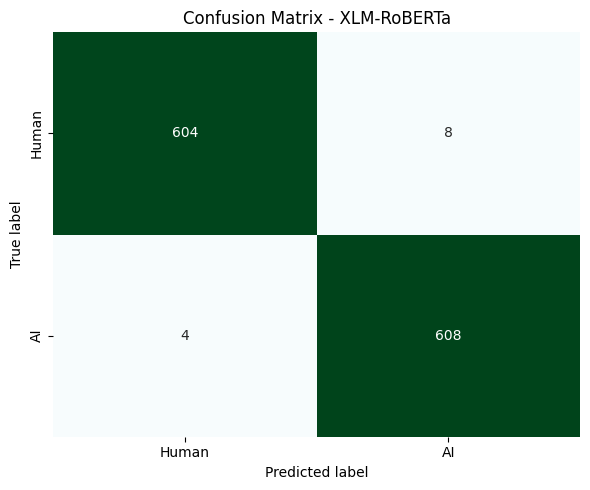

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

class_names = ["Human", "AI"]

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

conf_mat = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d",
    cmap="BuGn",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - XLM-RoBERTa")
plt.tight_layout()
plt.show()

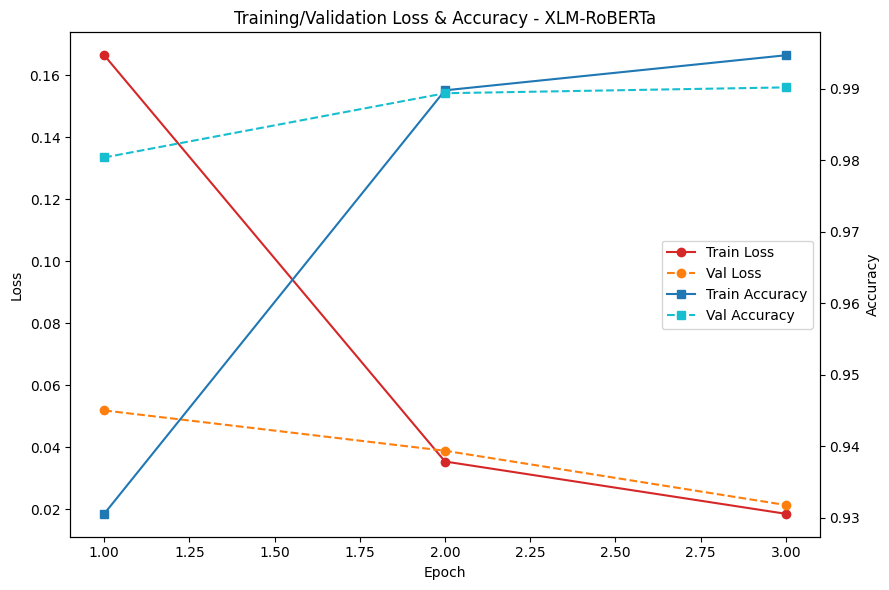

In [16]:
import matplotlib.pyplot as plt

hist = history.history
epochs_range = range(1, len(hist["loss"]) + 1)

fig, ax1 = plt.subplots(figsize=(9, 6))

#loss
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
line1 = ax1.plot(epochs_range, hist["loss"], color="tab:red", marker="o", label="Train Loss")
line2 = ax1.plot(epochs_range, hist["val_loss"], color="tab:orange", marker="o", linestyle="--", label="Val Loss")
ax1.tick_params(axis="y")

#accuracy
ax2 = ax1.twinx()
ax2.set_ylabel("Accuracy")
line3 = ax2.plot(epochs_range, hist["accuracy"], color="tab:blue", marker="s", label="Train Accuracy")
line4 = ax2.plot(epochs_range, hist["val_accuracy"], color="tab:cyan", marker="s", linestyle="--", label="Val Accuracy")
ax2.tick_params(axis="y")

#legend
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="center right")

plt.title("Training/Validation Loss & Accuracy - XLM-RoBERTa")
fig.tight_layout()
plt.show()

In [17]:
examples = {
    ("correct", 0): [],
    ("correct", 1): [],
    ("incorrect", 0): [],
    ("incorrect", 1): [],
}

max_per_group = 3

for i in range(len(y_true)):
    true_label = y_true[i]
    pred_label = y_pred[i]
    is_correct = (true_label == pred_label)
    key = ("correct" if is_correct else "incorrect", true_label)

    if len(examples[key]) < max_per_group:
        examples[key].append(X[i])

    if all(len(v) >= max_per_group for v in examples.values()):
        break

class_names = {0: "Human", 1: "AI"}

for (status, label), texts in examples.items():
    print(f"\n{'='*60}")
    print(f"{status.upper()} - class: {class_names[label]} ({len(texts)} examples)")
    print('='*60)
    for j, text in enumerate(texts, 1):
        print(f"\n[{j}] {text[:300]}{'...' if len(text) > 300 else ''}")


CORRECT - class: Human (3 examples)

[1] one interactive application to another. In this ples. If we apply OMG’s principles to the UI development life paper, we would like to review the main principles that under- cycle, it means that models should be obtained during steps of pin model-driven engineering of user interfaces in order to deve...

[2] Of course, a tool may induce some method, but this technologies with which to realize model-driven develop- process remains poorly defined in a way that is implicit to ment with automated transformations. Not all of these tech- the tool. A tool should be explicitly developed in order to nologies wil...

[3] UIs and to introduce based on explicit transformations rules that can be edited by the the audience to the development of UIs based on MDE based designer. Or because there is no genuine modelling language on this experience. The particular objective is to teach how to behind. It is not just because ...

CORRECT - class: AI (3 examples)

[

In [18]:
#model download

model.save_pretrained("./xlm-roberta-model")
tokenizer.save_pretrained("./xlm-roberta-model")

from google.colab import files
import shutil
shutil.make_archive("romanian-xlm-roberta-model", "zip", "./xlm-roberta-model")
files.download("romanian-xlm-roberta-model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>